# Week 04 — Machine Learning Pipeline

## Customer Churn Prediction

In this task, we build a professional machine learning pipeline using
Scikit-learn's ColumnTransformer and Pipeline.

The pipeline will:
- Preprocess numerical and categorical features
- Scale numerical features using StandardScaler
- Encode categorical features using OneHotEncoder
- Train a Logistic Regression model
- Create new engineered features
- Compare model performance before and after feature engineering
- Save the final pipeline using Joblib

## Objective

The goal of this task is to build a reusable machine learning pipeline
for predicting customer churn.

Using a pipeline helps ensure that preprocessing and model training are
performed consistently and reduces the risk of data leakage between the
training and testing datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum().sort_values(ascending=False).head(10)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

## Data Cleaning

The `TotalCharges` column may contain blank values and is stored as an
object in the original dataset.

These values will be converted to numeric format. Any resulting missing
values will be filled with 0 because customers with zero recorded
total charges are likely to have very low or zero tenure.

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["TotalCharges"].isnull().sum()

0

## Feature Engineering

Feature engineering creates new variables from existing data that may
help the machine learning model identify useful patterns.

For this task, two new features are created:

1. `AvgMonthlySpend` — average amount spent per month.
2. `TotalServices` — number of additional services subscribed to by a customer.

These features will later be tested to determine whether they improve
model performance.

In [7]:
df["AvgMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

df[["tenure", "TotalCharges", "AvgMonthlySpend"]].head()

,tenure,TotalCharges,AvgMonthlySpend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


In [8]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_columns]
    .apply(lambda row: (row == "Yes").sum(), axis=1)
)

df[["TotalServices"] + service_columns].head()

,TotalServices,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,No,No phone service,No,Yes,No,No,No,No
1,3,Yes,No,Yes,No,Yes,No,No,No
2,3,Yes,No,Yes,Yes,No,No,No,No
3,3,No,No phone service,Yes,No,Yes,Yes,No,No
4,1,Yes,No,No,No,No,No,No,No


## Target Variable

The target variable is `Churn`.

It represents whether a customer left the company:

- `Yes` → Customer churned
- `No` → Customer stayed

The target will be converted into binary values so that the classification
model can use it.

In [9]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Preparing Features and Target

`customerID` is removed because it is only an identifier and does not
provide meaningful predictive information.

The remaining columns are divided into numerical and categorical
features so that different preprocessing techniques can be applied
through `ColumnTransformer`.

In [10]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X.shape, y.shape

((7043, 21), (7043,))

In [11]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train-Test Split

The dataset is divided into training and testing sets.

The model will learn from the training data, while the test data will
only be used for final evaluation.

The preprocessing steps are placed inside the pipeline so that they are
fit only on the training data, helping prevent data leakage.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


## Building the Preprocessing Pipeline

`ColumnTransformer` allows us to apply different preprocessing techniques
to different types of features.

- Numerical features → StandardScaler
- Categorical features → OneHotEncoder

This keeps all preprocessing steps organized inside one reusable workflow.

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## Machine Learning Pipeline

The preprocessing step and Logistic Regression model are chained into
one pipeline.

This means the same preprocessing operations are automatically applied
during training and prediction.

In [14]:
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'TotalServices']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [15]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'TotalServices']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [16]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Pipeline Accuracy:", accuracy)

Pipeline Accuracy: 0.8069552874378992


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



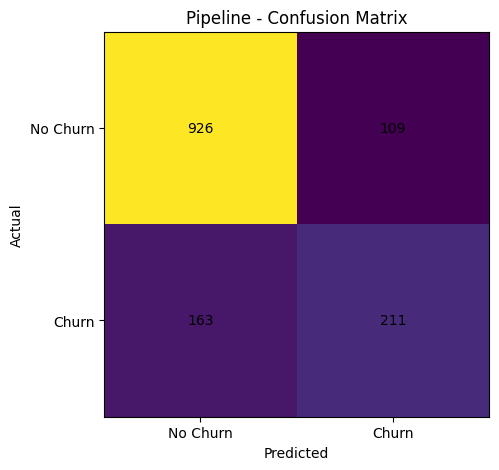

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Pipeline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Pipeline vs Manual Approach

The pipeline combines preprocessing and model training into a single workflow. This helps ensure that the same preprocessing steps are applied consistently to both training and testing data and reduces the risk of data leakage.

The pipeline performance is compared with the manual approach from the previous task.

In [20]:
# Make predictions using the trained pipeline
y_pred_pipeline = pipeline.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [21]:
from sklearn.metrics import accuracy_score, classification_report

pipeline_accuracy = accuracy_score(y_test, y_pred_pipeline)

print("Pipeline Accuracy:", pipeline_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pipeline))

Pipeline Accuracy: 0.8069552874378992

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Feature Engineering

Feature engineering can help a machine learning model discover useful patterns that may not be directly represented by the original variables.

Two new features are created:

- **TotalServices:** Counts the number of subscribed services.
- **AvgMonthlySpend:** Estimates the customer's average spending per month using TotalCharges and tenure.

In [22]:
df_engineered = df.copy()

# Total number of subscribed services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_engineered["TotalServices"] = (
    df_engineered[service_columns]
    .apply(lambda x: (x == "Yes").sum(), axis=1)
)

# Average monthly spending
df_engineered["AvgMonthlySpend"] = (
    df_engineered["TotalCharges"] / df_engineered["tenure"].replace(0, 1)
)

df_engineered[
    ["TotalServices", "AvgMonthlySpend"]
].head()

,TotalServices,AvgMonthlySpend
0,1,29.850000
1,3,55.573529
2,3,54.075000
3,3,40.905556
4,1,75.825000


In [23]:
df_engineered[
    ["tenure", "TotalCharges", "TotalServices", "AvgMonthlySpend"]
].describe()

,tenure,TotalCharges,TotalServices,AvgMonthlySpend
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2279.734304,3.362914,64.698218
std,24.559481,2266.794470,2.062031,30.270670
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,398.550000,1.000000,35.649000
50%,29.000000,1394.550000,3.000000,70.300000
75%,55.000000,3786.600000,5.000000,90.174158
max,72.000000,8684.800000,8.000000,121.400000


In [30]:
# Use the already prepared target variable
y_eng = y.copy()

# Reset index so X_eng and y_eng stay aligned
X_eng = X_eng.reset_index(drop=True)
y_eng = y_eng.reset_index(drop=True)

print("Missing values in y_eng:", y_eng.isnull().sum())
print("y_eng shape:", y_eng.shape)
print(y_eng.value_counts())

Missing values in y_eng: 0
y_eng shape: (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng,
    y_eng,
    test_size=0.2,
    random_state=42,
    stratify=y_eng
)

print("Training samples:", len(X_train_eng))
print("Testing samples:", len(X_test_eng))

Training samples: 5634
Testing samples: 1409


## Preparing Features for the Pipeline

The engineered dataset contains both numerical and categorical features.
Numerical features will be standardized, while categorical features will
be one-hot encoded using the preprocessing pipeline.

In [32]:
numerical_features_eng = X_train_eng.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_eng = X_train_eng.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features_eng)

print("\nCategorical features:")
print(categorical_features_eng)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'TotalServices']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Preprocessing with ColumnTransformer

ColumnTransformer allows different preprocessing methods to be applied
to different types of features.

Numerical features are scaled using StandardScaler, while categorical
features are converted into numerical form using OneHotEncoder.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_eng = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_eng
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_eng
        )
    ]
)

## Final Machine Learning Pipeline

The preprocessing step and Logistic Regression model are combined into
one pipeline. This ensures that the same preprocessing is automatically
applied during both training and prediction.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

final_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_eng),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

final_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'TotalServices']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [35]:
final_pipeline.fit(
    X_train_eng,
    y_train_eng
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'TotalServices']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [36]:
y_pred_eng = final_pipeline.predict(X_test_eng)

print("Predictions generated successfully.")

Predictions generated successfully.


## Performance Comparison

The engineered pipeline is compared with the original pipeline to check
whether the two newly created features improve model performance.

In [38]:
from sklearn.metrics import accuracy_score

engineered_accuracy = accuracy_score(
    y_test_eng,
    y_pred_eng
)

print("Original Pipeline Accuracy:", pipeline_accuracy)
print("Engineered Pipeline Accuracy:", engineered_accuracy)

Original Pipeline Accuracy: 0.8069552874378992
Engineered Pipeline Accuracy: 0.8076650106458482


## Final Model Evaluation

The classification report provides precision, recall, and F1-score for
both churned and non-churned customers.

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_eng,
        y_pred_eng
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



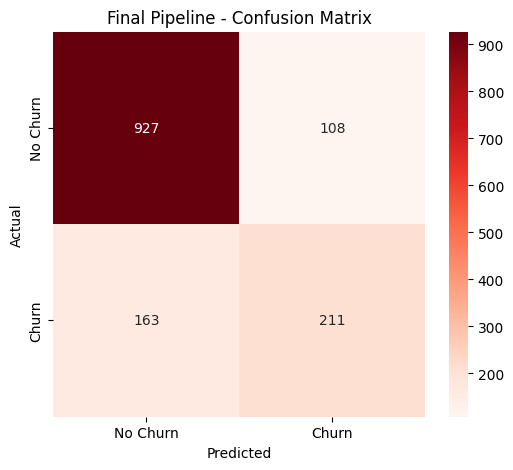

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_eng,
    y_pred_eng
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Final Pipeline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Saving the Final Pipeline

The trained pipeline is saved using Joblib. Saving the complete pipeline
allows the preprocessing and model to be reused together on new data.

In [41]:
import joblib

joblib.dump(
    final_pipeline,
    "final_churn_pipeline.joblib"
)

print("Final pipeline saved successfully!")

Final pipeline saved successfully!


In [42]:
import os

print(
    "Pipeline file exists:",
    os.path.exists("final_churn_pipeline.joblib")
)

Pipeline file exists: True


In [43]:
loaded_pipeline = joblib.load(
    "final_churn_pipeline.joblib"
)

loaded_predictions = loaded_pipeline.predict(
    X_test_eng
)

print("Saved pipeline loaded and tested successfully!")

Saved pipeline loaded and tested successfully!


### Performance Observation

The original pipeline achieved an accuracy of 80.70%, while the engineered
pipeline achieved 80.77% accuracy.

The engineered features improved the model performance slightly by about
0.07 percentage points.

This shows that TotalServices and AvgMonthlySpend provide some additional
information, but their impact on overall accuracy is limited.

## Final Conclusion

A complete machine learning pipeline was developed using ColumnTransformer,
StandardScaler, OneHotEncoder, and Logistic Regression.

Two engineered features, TotalServices and AvgMonthlySpend, were created
and tested. The engineered pipeline achieved 80.77% accuracy compared with
80.70% for the original pipeline.

The small improvement shows that the new features provide some useful
information, although their impact on overall model performance is limited.

The final pipeline was saved using Joblib so that the complete preprocessing
and model workflow can be reused for future predictions.